In [4]:
import os, sys, pickle
%pylab inline
from importlib import reload
import pandas as pd
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 3)
from tqdm import tqdm
from copy import deepcopy
import pickle

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [5]:
git_path = os.getenv("GIT")
proj_path = os.path.join(git_path, "glom-io-transform-release")
sys.path.append(proj_path)
os.chdir(proj_path + "/model_fitting")
os.getcwd()
os.environ["GLOM_IO"] = proj_path
os.environ["GLOM_IO_DATA"] = proj_path + "/data"

In [6]:
from odours import odours
import driver; reload(driver)
from driver import RunResults

In [4]:
from conn_models.quartic import Quartic

In [7]:
#! git pull
import conn_models; reload(conn_models)
from conn_models import common as models_common; reload(models_common)
from conn_models import diag as diag_model; reload(diag_model)
reload(driver)

<module 'driver' from '/nemo/lab/schaefera/working/tootoos/git/glom-io-transform-release/model_fitting/driver.py'>

In [8]:
import results; reload(results)
base = results.BaseContext(fits_root = proj_path + "/model_fitting/fits", models_dir=proj_path + "/model_fitting",
                          standardization="separate", normalization="odour_std", center=True)
trials = base.split(sampler="trials", mode="random", n_od_train="max")

Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model_fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.


Loading data from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/data/X0Y0_new.p
Assembling INPUTS.
Generating splits with TrialsSampler, n_train=10, train_odours=[33, 23, 38, 36, 2, 3, 31, 26, 44, 27, 28, 47, 21, 34, 19, 40, 35, 24, 22, 13, 39, 17, 46, 4, 29, 14, 10, 42, 32, 18, 41, 30, 20, 25, 6, 7, 45, 1, 16, 0, 15, 5, 11, 9, 8, 12, 43, 37]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by odour.
Assembling OUTPUTS.
Generating splits with TrialsSampler, n_train=10, train_odours=[33, 23, 38, 36, 2, 3, 31, 26, 44, 27, 28, 47, 21, 34, 19, 40, 35, 24, 22, 13, 39, 17, 46, 4, 29, 14, 10, 42, 32, 18, 41, 30, 20, 25, 6, 7, 45, 1, 16, 0, 15, 5, 11, 9, 8, 12, 43, 37]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by overall standard deviation.
init_args={'center': True, 'λ': np.float64(1e-08)}
Regularizing z**1 - 1
bounds (-inf, inf)
Running model...
Running minimization with 22

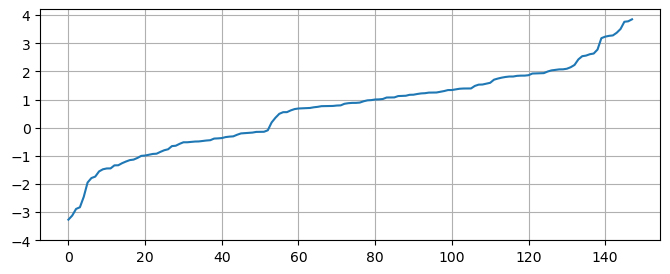

In [9]:
model = trials.model("Diag")
in_file = os.path.join(model.base_dir, "in.27.p")
assert os.path.exists(in_file), f"Input file {in_file} does not exist"
in_params = pickle.load(open(in_file, "rb"))
in_params["data_file"] = in_params["data_file"].replace("/camp/home/tootoos/working/tootoos/git", os.environ["GIT"])
in_params["sampler"]["n_train"] = 10 
in_params["min_args"]["options"]["gtol"]= 1e-8
res, dataset, mdl = driver.run(in_params, return_dataset=True, return_model=True)
plot(sorted(mdl.r)); grid(True); gca().set_yticks(arange(-4, 5, 1))

In [17]:
Q = mdl.compute_quartic_coefs()
Xn = norm(Q.X, axis=1)

All Xs were the same, so mean-of-XY-pairs quartic should be the same as fitting mean Cstar.
Q.[A|B|C|D] = Q_mean.[A|B|C|D]: OK.


In [19]:
from numpy.lib.scimath import sqrt as csqrt
xn       = norm(mdl.Xs[0],axis=1)
XU       = Q.X/xn[:,None]
mu       = Q.mi_ / (Q.mi_.shape[0] -1)
mu_n     = mu / norm(mu, axis=1)[:, None]
c        = sum(XU * mu, axis=1)
cos_th_i = sum(XU * mu_n, axis=1)
th_i     = arccos(cos_th_i)
K = 2 * csqrt(-Q.g_/3)
u = -4 * Q.h_ / K**3

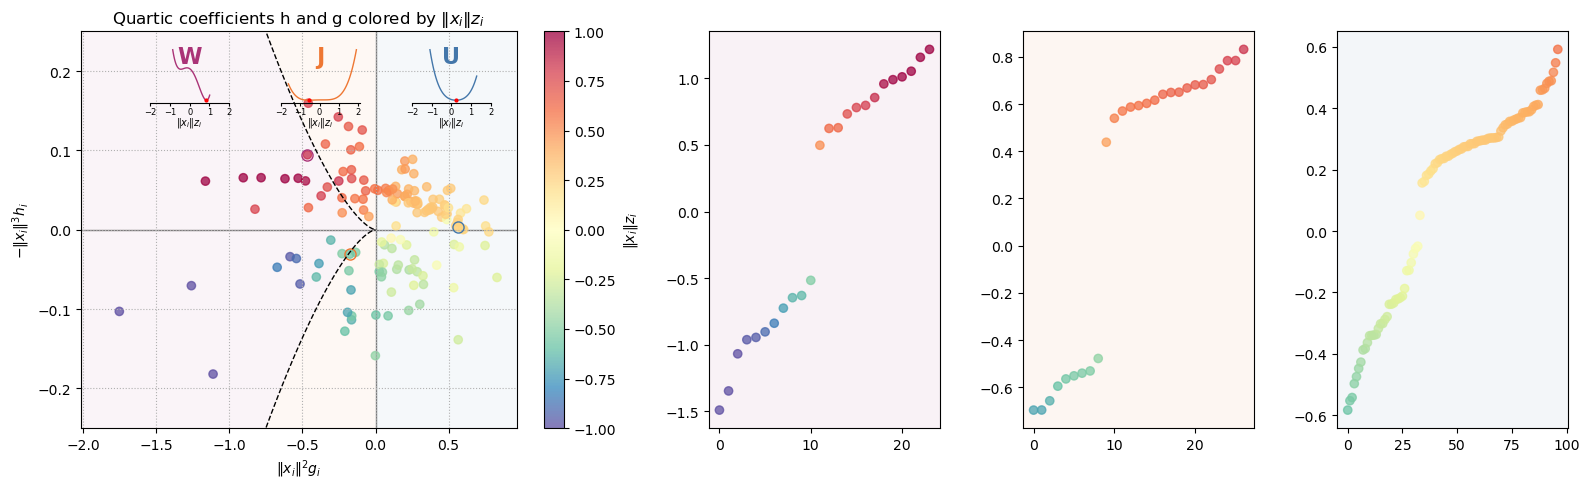

In [15]:
# Plot the p-q plane
from matplotlib.gridspec import GridSpec
gs = GridSpec(1, 5)
figure(figsize=(16,5))
ax1 = subplot(gs[0,:2])
zz = Q.z * Xn
color_by_dict = {"$z-1$":(Q.z-1, -5, 5, "seismic"),
            "$z$":(Q.z, -4, 4, "Spectral_r"),
            "$\\|x_i\\|z_i$":(zz, -1,1, "Spectral_r"),
            "$k$":(Q.C_, -0.25, 0.25, "coolwarm"),
            "$|z|$":(np.abs(Q.z), 0, 5, "viridis"),
            "$s$": (np.sign(Q.z), -1, 1, "bwr")
}
which_scheme = "$\\|x_i\\|z_i$"
color_by = color_by_dict[which_scheme]
gg =  Q.g_.copy() * Xn**(2*1)
hh = -Q.h_.copy() * Xn**(3*1)
scatter(gg, hh, c = color_by[0], alpha=0.75, cmap=color_by[3], vmin=color_by[1], vmax=color_by[2])
grid(True, linestyle=":")
axhline(0, zorder=-1, lw=1, color="k", alpha=0.5)
axvline(0, zorder=-1, lw=1, color="k", alpha=0.5)
#scatter(Q._p, Q._q, c = Q._c, cmap="rainbow")
ii = np.argsort(Q.z)
in_W = (gg < 0) & (hh**2 < (4/27) * np.abs(gg)**3)
in_V = (gg < 0) & (~in_W)
in_U = (gg > 0)
region_colors = {"U": "#4477AA", "J": "#EE7733", "W": "#AA3377"}
exemplars = {}
for name, mask in [("U", in_U), ("J", in_V), ("W", in_W)]:
    idx = where(mask)[0]
    if len(idx): exemplars[name] = idx[:11][-1] if name == "W" else idx[len(idx)//2]
for name, wi in exemplars.items():
    plot(gg[wi], hh[wi], "o", color=region_colors[name], markerfacecolor="none", markersize=8)
#plot(gg[in_W], hh[in_W], "k.", markersize=2)
xlabel("$\|x_i\|^2 g_i $"); ylabel("$-\|x_i\|^3 h_i$"); title(f"Quartic coefficients h and g colored by {which_scheme}")
colorbar(label=which_scheme)
gvals = np.linspace(min(xlim()), 0, 100)
# Plot the cusp curve: 27 q^2 = 8 (-p)^3
cusp_h = np.sqrt(4/27 * (-gvals)**3)
plot(gvals, cusp_h, "k--", lw=1, label="Cusp curve"); plot(gvals, -cusp_h, "k--", lw=1);# legend(loc="lower right")
ax1.set_ylim(-0.25, 0.25)
# Shade the U, V, W regions
x0, x1 = xlim(); y0, y1 = ylim()
gv = np.linspace(x0, 0, 200)
ch = np.sqrt(4/27 * (-gv)**3)
ax1.axvspan(0, x1, color="#4477AA", alpha=0.05, lw=0, zorder=-2)             # U: g > 0
ax1.fill_between(gv, ch,  y1, color="#EE7733", alpha=0.05, lw=0, zorder=-2)   # V: g < 0, above the cusp
ax1.fill_between(gv, y0, -ch, color="#EE7733", alpha=0.05, lw=0, zorder=-2)  # V: g < 0, below the cusp
ax1.fill_between(gv, -ch, ch, color="#AA3377", alpha=0.05, lw=0, zorder=-2)  # W: between the cusp branches
ax1.text(0.85, 0.92, "U", color="#4477AA", transform=ax1.transAxes, ha="center", fontsize=16, fontweight="bold")
ax1.text(0.55, 0.92, "J", color="#EE7733", transform=ax1.transAxes, ha="center", fontsize=16, fontweight="bold")
ax1.text(0.25, 0.92, "W", color="#AA3377", transform=ax1.transAxes, ha="center", fontsize=16, fontweight="bold")
xlim(x0, x1); ylim(y0, y1)
# Insets: floating loss quartics, one exemplar per region
def add_loss_inset(i, xc, color):
    axi = ax1.inset_axes([xc - 0.09, 0.82, 0.18, 0.14])
    zv = np.linspace(Q.z.min(), Q.z.max(), 100)
    axi.plot(zv*Xn[i], Q.LiFUN(i, zv), lw=1, color=color)
    axi.plot(Q.z[i]*Xn[i], Q.LiFUN(i, Q.z[i]), "r.", markersize=4)
    axi.patch.set_alpha(0)   # transparent: just a floating quartic
    [axi.spines[s].set_visible(False) for s in ["top", "right", "left"]]
    axi.set_yticks([]); axi.set_xticks(np.arange(-2, 3, 1))
    axi.set_xlabel("$\|x_i\|z_i$", fontsize=7, labelpad=-1)
    axi.tick_params(labelsize=6, length=2, pad=1)
    return axi

inset_x = {"U": 0.85, "J": 0.55, "W": 0.25}   # axes fractions, centered under each region label
for name, wi in exemplars.items():
    add_loss_inset(wi, inset_x[name], region_colors[name])

axes = {"W": subplot(gs[0,2]),
        "J": subplot(gs[0,3]),
        "U": subplot(gs[0,4])}

for name in "WJU":
    ax = axes[name]
    mask = {"W": in_W, "J": in_V, "U": in_U}[name]
    zz_sub = zz[mask]
    order = np.argsort(zz_sub)
    ax.scatter(arange(len(order)), zz_sub[order], c = color_by[0][mask][order], alpha=0.75, cmap=color_by[3], vmin=color_by[1], vmax=color_by[2])
    # Color the axis according to the region's color
    # Add alpha to the color to make it lighter
    ax_col = region_colors[name] + "10"  # Adding '33' for alpha transparency
    ax.set_facecolor(ax_col)

tight_layout()

# W-responses

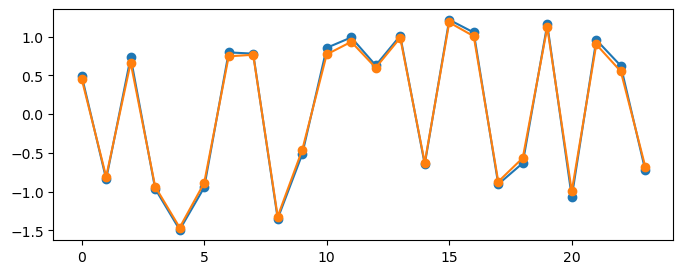

In [111]:
zz = Q.z * xn
ss = sqrt(np.abs(Q.g_)) * xn * sign(-Q.h_)
plot(zz[in_W], "o-")
plot(c[in_W] + ss[in_W], "o-")

# V-responses

/tmp/ipykernel_384746/385240919.py:1: RuntimeWarning: invalid value encountered in arccosh
  ss = (cosh(1/3*arccosh(abs(u)))) * K * xn * sign(-Q.h_)


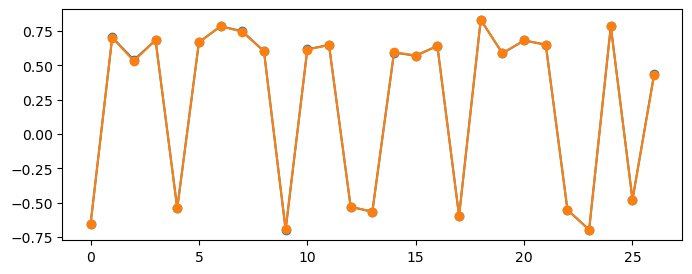

In [113]:
ss = (cosh(1/3*arccosh(abs(u)))) * K * xn * sign(-Q.h_)
plot(zz[in_V], "o-")
plot(c[in_V] + ss[in_V], "o-")

# U-responses

(-1.0, 1.0)

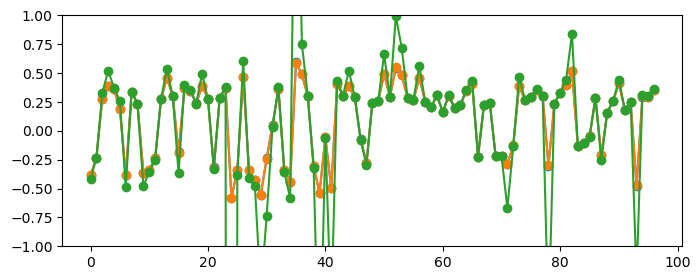

In [129]:
ss = imag(K) * sinh(1/3*arcsinh(imag(u)))
ss1 = imag(K) * imag(u)/3
plot(zz[in_U], "o-")
plot(c[in_U] + ss[in_U]*xn[in_U], "o-")
plot(c[in_U] + ss1[in_U]*xn[in_U], "o-")
ylim([-1,1])
